In [ ]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import glob


In [ ]:
# Set global matplotlib formatting for ICLR paper compatibility

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,  # TrueType fonts for compatibility
    'ps.fonttype': 42,
    'text.usetex': False,  # Set to True if you want LaTeX rendering and have it installed
    'axes.spines.top': False,
    'axes.spines.right': False,
})

import seaborn as sns
sns.set_context("paper")
sns.set_style("whitegrid")


In [7]:
cwd = os.getcwd()
file1 = './results/sweep_L_A/data_max_move_1_L_9.pkl'
file2 = './results/sweep_L_A/data_max_move_15_L_9.pkl'
data_dict_l = [pkl.load(open(file1, 'rb')), pkl.load(open(file2, 'rb'))]

X shape: (88, 33) --- U shape: (30, 30) --- V shape: (30, 33)
X shape: (690, 61) --- U shape: (30, 30) --- V shape: (30, 61)


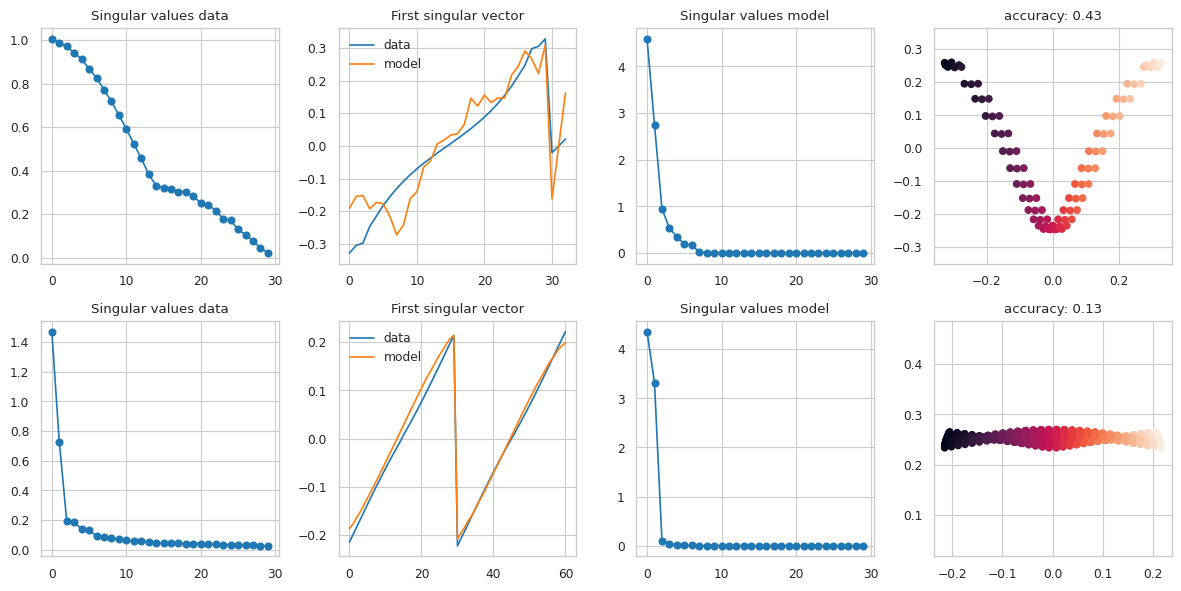

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs_l = plt.subplots(2, 4, figsize=(4*3, 6))

for data_dict, axs in zip(data_dict_l, axs_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    W /= np.linalg.norm(W, axis=0)
    U, S, V = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    print(f'X shape: {X.shape} --- U shape: {U.shape} --- V shape: {V.shape}')
    rank = 1
    axs[0].plot(S, marker='o')
    axs[0].set_title('Singular values data')
    axs[1].plot(V[:rank].T, label='data')

    U, S, V = np.linalg.svd(W, full_matrices=False)
    axs[1].plot(U[:, :rank], label='model')
    axs[1].legend()
    axs[1].set_title('First singular vector')
    axs[2].plot(S, marker='o')
    axs[2].set_title('Singular values model')
    plt.tight_layout()
    

    W_corr = Sigma31@np.linalg.pinv(Sigma11)
    U, S, V = np.linalg.svd(W_corr.T, full_matrices=False)
    for cor, marker in zip(np.unique(corridor), markers):
        axs[-1].scatter(X[corridor==cor]@U[:, 0], X[corridor==cor]@U[:, 1], c=y[corridor==cor].argmax(1), marker=marker)
    axs[-1].set_title(f'accuracy: {calc_accuracy_from_W(W_corr.T, X, y):.2f}')
    axs[-1].axis('equal')
os.makedirs('./final_results/figures', exist_ok=True)
fig.savefig('./final_results/figures/fig3.png', dpi=300)
plt.show()
